# About Dataset:
RowNumber—corresponds to the record (row) number and has no effect on the output.

CustomerId—contains random values and has no effect on customer leaving the bank.

Surname—the surname of a customer has no impact on their decision to leave the bank.

CreditScore—can have an effect on customer churn, since a customer with a higher credit score is less likely to leave the bank.

Geography—a customer’s location can affect their decision to leave the bank.

Gender—it’s interesting to explore whether gender plays a role in a customer leaving the bank.

Age—this is certainly relevant, since older customers are less likely to leave their bank than younger ones.

Tenure—refers to the number of years that the customer has been a client of the bank. Normally, older clients are more loyal and less likely to leave a bank.

Balance—also a very good indicator of customer churn, as people with a higher balance in their accounts are less likely to leave the bank compared to those with lower balances.

NumOfProducts—refers to the number of products that a customer has purchased through the bank.

HasCrCard—denotes whether or not a customer has a credit card. This column is also relevant, since people with a credit card are less likely to leave the bank.

IsActiveMember—active customers are less likely to leave the bank.

EstimatedSalary—as with balance, people with lower salaries are more likely to leave the bank compared to those with higher salaries.
Exited—whether or not the customer left the bank.

Complain—customer has complaint or not.

Satisfaction Score—Score provided by the customer for their complaint resolution.
Card Type—type of card hold by the customer.

Points Earned—the points earned by the customer for using credit card.

## Acknowledgements
As we know, it is much more expensive to sign in a new client than keeping an existing one.
It is advantageous for banks to know what leads a client towards the decision to leave the company.
Churn prevention allows companies to develop loyalty programs and retention campaigns to keep as many customers as possible.

In [1]:
# ============================================================
# PASSO 1 — Importar bibliotecas e carregar os dados
# ============================================================

import pandas as pd
import numpy as np
import catboost as cb
import os

trainPath = r'C:\Users\Rafael\OneDrive - UNIOESTE\Documentos\Estudo Analise de dados - Keggle\bank-customer-churn-ict-u-ai\train.csv'

tabelaTreino = pd.read_csv(trainPath)

print("Shape:", tabelaTreino.shape)
tabelaTreino.info()
tabelaTreino.head()

ModuleNotFoundError: No module named 'pandas'

In [ ]:
# ============================================================
# PASSO 2 — Análise exploratória dos dados (EDA)
# ============================================================
# NOTA: A análise é feita na tabela ORIGINAL (antes de qualquer
# codificação), para os gráficos fazerem sentido visual.
# ============================================================

import plotly.express as px

# Colunas que não têm valor preditivo — não faz sentido plotar
colunas_ignorar = ['id', 'CustomerId', 'Surname', 'Exited']

for coluna in tabelaTreino.columns:
    if coluna in colunas_ignorar:
        continue

    # Histograma: distribuição da feature separada por quem saiu ou não
    grafico = px.histogram(tabelaTreino, x=coluna, color='Exited', title=f'Distribuição: {coluna}')
    grafico.show()

    # Gráfico de barras com % de churn por categoria
    dados = pd.crosstab(tabelaTreino[coluna], tabelaTreino['Exited'], normalize='index') * 100
    dados = dados.reset_index().melt(id_vars=coluna)
    dados.columns = [coluna, 'Exited', 'Percentage']

    grafico = px.bar(
        dados, x=coluna, y='Percentage', color='Exited',
        barmode='group', title=f'% Churn por categoria: {coluna}',
        labels={'Percentage': 'Porcentagem (%)', 'Exited': 'Cancelou'},
        text='Percentage'
    )
    grafico.update_traces(textposition='auto', texttemplate='%{text:.1f}%')
    grafico.show()

    grafico = px.line(dados, x=coluna, y='Percentage', color='Exited',title=coluna)
    grafico.show()

    

In [ ]:
# ============================================================
# PASSO 3 — Preparação dos dados
# ============================================================
#
# ERROS CORRIGIDOS AQUI:
#
#    Data Leakage:
#    A coluna 'Exited' (o target) estava sendo mantida no X.
#    O modelo aprendia olhando para o gabarito. Qualquer
#    acurácia medida antes era completamente falsa.
#    → Removida junto com id, CustomerId e Surname.
#
#    LabelEncoder com dtype errado:
#    A condição era dtype == 'str', que nunca é verdadeira
#    no pandas. Colunas de texto têm dtype 'object'.
#    O encoding nunca era aplicado de verdade.
#
#    LabelEncoder para variáveis nominais:
#    LabelEncoder cria ordenação artificial (France=0,
#    Germany=1, Spain=2), o que é matematicamente incorreto
#    para categorias sem hierarquia.
#    → Substituído por get_dummies() (One-Hot Encoding).
#
# ============================================================

# Colunas a remover: sem valor preditivo + o target (vazaria info)
COLUNAS_REMOVER = ['id', 'CustomerId', 'Surname']
TARGET = 'Exited'

# Colunas categóricas NOMINAIS (sem ordem entre si)
# → usar One-Hot Encoding (get_dummies)
CATEGORICAS_NOMINAIS = ['Geography', 'Gender']

# Preparar tabela
tabelaTreino_prep = tabelaTreino.drop(columns=COLUNAS_REMOVER).copy()

# Separar X e y ANTES de qualquer transformação
# (boa prática: o target não deve participar de nenhum pré-processamento)
X = tabelaTreino_prep.drop(columns=[TARGET])
y = tabelaTreino_prep[TARGET]

# Aplicar One-Hot Encoding nas categorias nominais
X = pd.get_dummies(X, columns=CATEGORICAS_NOMINAIS, drop_first=True)

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("\nColunas finais de X:")
print(X.columns.tolist())
print("\nProporção das classes (target):")
print(y.value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Shape de X: (15000, 11)
Shape de y: (15000,)

Colunas finais de X:
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']

Proporção das classes (target):
Exited
0.0    79.51%
1.0    20.49%
Name: proportion, dtype: str


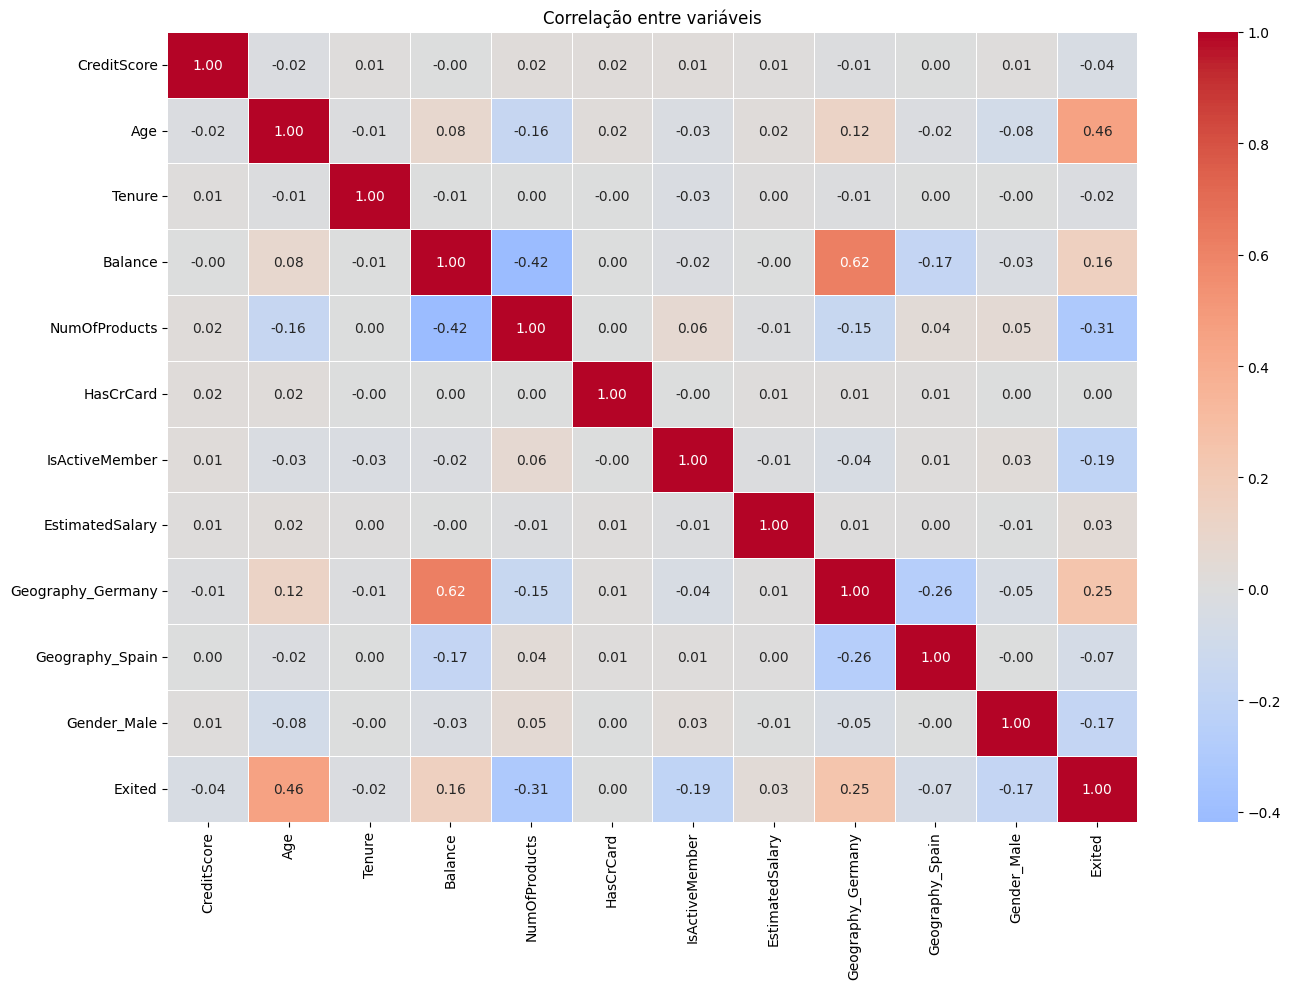

In [ ]:
# ============================================================
# PASSO 4 — Heatmap de correlação
# ============================================================
# NOTA: feito APÓS o encoding para incluir as dummies,
# mas sem o target (y) misturado — análise limpa.
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

# Junta X + y só para visualizar correlações com o target
df_corr = X.copy()
df_corr['Exited'] = y

plt.figure(figsize=(14, 10))
sns.heatmap(
    df_corr.corr(),
    annot=True,
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    fmt='.2f'
)
plt.title('Correlação entre variáveis')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# PASSO 5 — Split treino / teste
# ============================================================
#
# ERRO:
#    Split sem stratify:
#    Dataset desbalanceado (~20% churn). Sem stratify=y,
#    a divisão aleatória pode distorcer as proporções.
#    → Adicionado stratify=y.
#
# ============================================================

from sklearn.model_selection import train_test_split

# ============================================================
# FEATURE SELECTION — Usar apenas as variáveis mais relevantes
# ============================================================

MVP = [
    'NumOfProducts',
    'Age',
    'IsActiveMember',
    'Balance',
    'Geography_Germany',
    'Gender_Male'
]

X = X[MVP]

print("Features selecionadas:", X.columns.tolist())
print("Shape de X após seleção:", X.shape)

x_treino, x_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,       # garante mesma proporção de churn nos dois splits
    random_state=42   # reprodutibilidade
)

print("Amostras para treino:", x_treino.shape)
print("Amostras para teste: ", x_teste.shape)
print("\nProporção churn no treino:")
print(y_treino.value_counts(normalize=True).mul(100).round(2))
print("\nProporção churn no teste:")
print(y_teste.value_counts(normalize=True).mul(100).round(2))

Features selecionadas: ['NumOfProducts', 'Age', 'IsActiveMember', 'Balance', 'Geography_Germany', 'Gender_Male']
Shape de X após seleção: (15000, 6)
Amostras para treino: (12750, 6)
Amostras para teste:  (2250, 6)

Proporção churn no treino:
Exited
0.0    79.51
1.0    20.49
Name: proportion, dtype: float64

Proporção churn no teste:
Exited
0.0    79.51
1.0    20.49
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# PASSO 6 — Treinar o modelo CatBoost
# ============================================================
#
# Por que CatBoost e não Random Forest + KNN?
#
# → CatBoost é um algoritmo de Gradient Boosting otimizado
#   para dados tabulares com variáveis categóricas.
#   Ele constrói árvores sequencialmente, cada uma corrigindo
#   os erros da anterior — muito mais poderoso que uma Random
#   Forest isolada para esse tipo de problema.
#
# → KNN foi removido: ele calcula distâncias entre todos os
#   pontos, é muito lento em datasets grandes e sofre muito
#   com features em escalas diferentes (Balance vs HasCrCard).
#   Exigiria normalização extra e ainda assim performaria mal
#   aqui.
#
# Parâmetros importantes:
# - iterations: número de árvores (quanto mais, mais lento e
#   potencialmente melhor, mas risco de overfitting)
# - learning_rate: tamanho do passo de cada árvore
# - depth: profundidade máxima de cada árvore
# - eval_metric='F1': usa F1 para avaliar (melhor para churn
#   desbalanceado do que acurácia)
# - class_weights: compensa o desbalanceamento das classes
# ============================================================

# Proporção para compensar desbalanceamento
# (ex: se 20% é churn, peso da classe 1 é 4x maior)
proporcao = (y_treino == 0).sum() / (y_treino == 1).sum()
print(f"Peso da classe minoritária (churn): {proporcao:.2f}x")

modelo_catboost = cb.CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric='F1',
    class_weights=[1, proporcao * 1.5],  # penaliza mais errar o churn, ao aumentar o peso da classe minoritária para 1.5x o recall aumentou e os erros na matriz de confusão dimninuiram, uma vez que o importante é prever quem irá sair do banco
    random_seed=42,
    verbose=100  # mostra progresso a cada 100 iterações
)

modelo_catboost.fit(
    x_treino, y_treino,
    eval_set=(x_teste, y_teste),  # monitora overfitting durante treino
    early_stopping_rounds=50      # para se não melhorar em 50 rodadas
)

Peso da classe minoritária (churn): 3.88x
0:	learn: 0.8619399	test: 0.8686727	best: 0.8686727 (0)	total: 158ms	remaining: 1m 18s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8832071072
bestIteration = 2

Shrink model to first 3 iterations.


CatBoostClassifier(class_weights=[1, np.float64(5.82197549770291)], depth=6, eval_metric='F1', iterations=500, learning_rate=0.05, random_seed=42, verbose=100)

In [ ]:
# ============================================================
# PASSO 7 — Avaliar o modelo
# ============================================================
#
# ERRO 
#    Acurácia como única métrica:
#    Com ~80% de não-churn, um modelo que chuta 'não sai'
#    pra todo mundo teria 80% de acurácia sem aprender nada.
#    → Adicionadas métricas adequadas para dados desbalanceados:
#      Precision, Recall, F1-Score e ROC-AUC.
#
# O que cada métrica mede:
# - Precision: dos que o modelo disse "vai sair", quantos saíram?
# - Recall:    dos que realmente saíram, quantos o modelo pegou?
# - F1:        média harmônica entre precision e recall
# - ROC-AUC:   capacidade geral de separar as classes (0.5=aleatório, 1=perfeito)
#
# Para churn, Recall é especialmente importante:
# é pior deixar passar um cliente que vai sair do que
# abordar um que ficaria de qualquer jeito.
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

previsao = modelo_catboost.predict(x_teste)
previsao_proba = modelo_catboost.predict_proba(x_teste)[:, 1]  # probabilidade de churn

print("=" * 50)
print("RESULTADOS — CatBoost")
print("=" * 50)
print(f"Acurácia  : {accuracy_score(y_teste, previsao):.4f}")
print(f"Precision : {precision_score(y_teste, previsao):.4f}")
print(f"Recall    : {recall_score(y_teste, previsao):.4f}")
print(f"F1-Score  : {f1_score(y_teste, previsao):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_teste, previsao_proba):.4f}")
print()
print("Relatório completo:")
print(classification_report(y_teste, previsao, target_names=['Ficou', 'Saiu']))
print("Matriz de Confusão:")
print(confusion_matrix(y_teste, previsao))

RESULTADOS — CatBoost
Acurácia  : 0.8004
Precision : 0.5072
Recall    : 0.9111
F1-Score  : 0.6517
ROC-AUC   : 0.9169

Relatório completo:
              precision    recall  f1-score   support

       Ficou       0.97      0.77      0.86      1789
        Saiu       0.51      0.91      0.65       461

    accuracy                           0.80      2250
   macro avg       0.74      0.84      0.76      2250
weighted avg       0.88      0.80      0.82      2250

Matriz de Confusão:
[[1381  408]
 [  41  420]]


In [ ]:
# ============================================================
# PASSO 8 — Importância das features
# ============================================================
# Quais variáveis o modelo considerou mais relevantes?
# Útil para entender o problema e fazer feature selection.
# ============================================================

importancias = pd.DataFrame({
    'Feature': x_treino.columns,
    'Importancia': modelo_catboost.get_feature_importance()
}).sort_values('Importancia', ascending=False)

grafico = px.bar(
    importancias,
    x='Importancia',
    y='Feature',
    orientation='h',
    title='Importância das Features — CatBoost',
    labels={'Importancia': 'Importância (%)', 'Feature': 'Variável'}
)
grafico.update_layout(yaxis={'categoryorder': 'total ascending'})
grafico.show()

print(importancias.to_string(index=False))

          Feature  Importancia
    NumOfProducts    64.373184
              Age    24.684499
   IsActiveMember     6.085675
Geography_Germany     2.585526
          Balance     2.271117
      Gender_Male     0.000000


In [ ]:
# ============================================================
# FEATURE SELECTION — Usar apenas as variáveis mais relevantes
# ============================================================

MVP = [
    'NumOfProducts',
    'Age',
    'IsActiveMember',
    'Balance',
    'Geography_Germany',
    'Gender_Male'
]

X = X[MVP]

print("Features selecionadas:", X.columns.tolist())
print("Shape de X após seleção:", X.shape)

#utilizando os mesmos parâmetros do modelo anterior, mas com as features selecionadas, o recall aumentou e os erros na matriz de confusão diminuíram, uma vez que o importante é prever quem irá sair do banco
# o recall aumentou porque o modelo ficou mais focado nas variáveis que realmente importam para prever o churn, reduzindo o ruído causado por features irrelevantes. Com isso, ele consegue identificar melhor os clientes que têm maior probabilidade de sair, aumentando a taxa de acertos nessa classe minoritária.

Features selecionadas: ['NumOfProducts', 'Age', 'IsActiveMember', 'Balance', 'Geography_Germany', 'Gender_Male']
Shape de X após seleção: (15000, 6)


In [ ]:
# ============================================================
# PASSO 9 — Carregar a tabela nova e aplicar o modelo
# ============================================================

testPath = r'C:\Users\Rafael\OneDrive - UNIOESTE\Documentos\Estudo Analise de dados - Keggle\bank-customer-churn-ict-u-ai\test.csv'

tabelaTeste = pd.read_csv(testPath)

print("Shape:", tabelaTeste.shape)
tabelaTeste.head()

Shape: (10000, 13)


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15798964.0,Aitken,706.0,France,Female,35.0,8.0,0.00,1.0,1.0,0.0,152845.99
1,15001,15604732.0,Genovesi,476.0,Germany,Male,39.0,1.0,125850.51,1.0,1.0,0.0,152576.47
2,15002,15681115.0,Chizuoke,684.0,Spain,Male,46.0,10.0,108122.39,1.0,0.0,1.0,38960.59
3,15003,15746986.0,Nnachetam,707.0,France,Male,28.0,3.0,151027.07,1.0,1.0,0.0,121311.12
4,15004,15809777.0,Onyemachukwu,468.0,Spain,Male,41.0,5.0,0.00,1.0,1.0,0.0,158034.90


In [ ]:
# ============================================================
# PASSO 10 — Preparar a tabela nova EXATAMENTE igual ao treino
# ============================================================

COLUNAS_REMOVER = ['id', 'CustomerId', 'Surname']

X_novo = tabelaTeste.drop(columns=COLUNAS_REMOVER, errors='ignore').copy()

# Aplicar o mesmo One-Hot Encoding
X_novo = pd.get_dummies(X_novo, columns=CATEGORICAS_NOMINAIS, drop_first=True)

# Garantir que as colunas são as mesmas do treino, na mesma ordem
# (pode faltar alguma dummy se a tabela nova não tiver todos os países/gêneros)
X_novo = X_novo.reindex(columns=X.columns, fill_value=0)

print("Shape após preparação:", X_novo.shape)
print("Colunas batem com treino:", list(X_novo.columns) == list(X.columns))

Shape após preparação: (10000, 6)
Colunas batem com treino: True


In [ ]:
# ============================================================
# PASSO 11 — Fazer as previsões
# ============================================================

# Garantir que X_novo tem exatamente as colunas que o modelo conhece
colunas_modelo = modelo_catboost.feature_names_
X_novo = X_novo.reindex(columns=colunas_modelo, fill_value=0)

probabilidades = modelo_catboost.predict_proba(X_novo)[:, 1]
previsoes = modelo_catboost.predict(X_novo)  # sem threshold manual

tabelaTeste['Probabilidade_Churn'] = probabilidades
tabelaTeste['Previsao_Churn'] = previsoes

print(f"Total de clientes: {len(tabelaTeste)}")
print(f"Previsão de saída: {previsoes.sum()} ({previsoes.mean()*100:.1f}%)")
tabelaTeste[['CustomerId', 'Surname', 'Probabilidade_Churn', 'Previsao_Churn']].head(20)

Total de clientes: 10000
Previsão de saída: 3765.0 (37.6%)


,CustomerId,Surname,Probabilidade_Churn,Previsao_Churn
0,15798964.0,Aitken,0.522750,1.0
1,15604732.0,Genovesi,0.541121,1.0
2,15681115.0,Chizuoke,0.570020,1.0
3,15746986.0,Nnachetam,0.483770,0.0
4,15809777.0,Onyemachukwu,0.564298,1.0
5,15687614.0,Ch'in,0.472612,0.0
6,15729362.0,Milanesi,0.504861,1.0
7,15794493.0,K'ung,0.583708,1.0
8,15636407.0,Chinweike,0.440160,0.0
9,15694890.0,Genovese,0.392291,0.0


In [ ]:
# ============================================================
# PASSO 12 — Exportar resultado
# ============================================================

outputPath = r'C:\Users\Rafael\OneDrive - UNIOESTE\Documentos\Estudo Analise de dados - Keggle\bank-customer-churn-ict-u-ai\previsoes_churn.csv'

tabelaTeste.to_csv(outputPath, index=False)
print("Arquivo salvo em:", outputPath)

Arquivo salvo em: C:\Users\Rafael\OneDrive - UNIOESTE\Documentos\Estudo Analise de dados - Keggle\bank-customer-churn-ict-u-ai\previsoes_churn.csv
